In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt


In [9]:
import sys
!{sys.executable} -m pip install tqdm sklearn


  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

In [10]:
import sys
!{sys.executable} -m pip install tensorflow keras numpy matplotlib pandas opencv-python albumentations


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import cv2
import numpy as np

DATA_DIR = 'flowers' 
IMG_SIZE = 224 

def load_data():
    images = []
    labels = []
    
    # Klasör var mı kontrolü
    if not os.path.exists(DATA_DIR):
        print(f"HATA: '{DATA_DIR}' klasörü bulunamadı. Lütfen klasör ismini kontrol et.")
        return np.array([]), np.array([]), []

    # Sadece klasör olanları al (gizli dosyaları eler)
    CLASSES = [f for f in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, f))]
    
    for label_id, class_name in enumerate(CLASSES):
        class_path = os.path.join(DATA_DIR, class_name)
        print(f"Yükleniyor: {class_name}")
        
        # DİKKAT: Bu for döngüsü bir üstteki print ile aynı hizada olmalı
        for img_name in os.listdir(class_path):
            try:
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path)
                if img is None: continue # Bozuk dosya kontrolü
                
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                
                images.append(img)
                labels.append(label_id)
            except Exception:
                continue
                
    return np.array(images), np.array(labels), CLASSES

# Veriyi yükle
X, y, class_names = load_data()

if len(X) > 0:
    print(f"\n--- Yükleme Tamamlandı ---")
    print(f"Toplam Görsel: {len(X)}")
    print(f"Tespit Edilen Sınıflar: {class_names}")

Yükleniyor: daisy
Yükleniyor: dandelion
Yükleniyor: rose
Yükleniyor: sunflower
Yükleniyor: tulip

--- Yükleme Tamamlandı ---
Toplam Görsel: 4317
Tespit Edilen Sınıflar: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [6]:
import sys
!{sys.executable} -m pip install scikit-learn


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
num_classes = len(class_names) 

# 1. Hazır Modeli Yükle
# include_top=False: Son sınıflandırma katmanını dahil etmiyoruz
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# 2. Mevcut ağırlıkları dondur (Hızlı eğitim ve başarı için)
base_model.trainable = False

# 3. Yeni Model Mimarisi
model = models.Sequential([
    # Giriş katmanı (Senin 0-1 arası normalizasyonuna uygun hale getiriyoruz)
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Lambda(lambda x: (x * 2.0) - 1.0), # [0,1] -> [-1,1] dönüşümü (MobileNet beklentisi)
    
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4), # Aşırı öğrenmeyi (overfitting) engellemek için
    layers.Dense(num_classes, activation='softmax')
])

# 4. Derleme
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 20s 2us/step



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
from sklearn.model_selection import train_test_split

# Veriyi bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalizasyon: 0-255 arası değerleri 0-1 arasına çekiyoruz
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (3453, 224, 224, 3)
Test seti boyutu: (864, 224, 224, 3)


In [7]:
# Eğitim parametrelerini güncelleyelim
history = model.fit(
    X_train, y_train,
    epochs=10, # Hazır modelle 10 epoch genellikle yeterlidir
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 57s 486ms/step - accuracy: 0.7944 - loss: 0.5664 - val_accuracy: 0.8877 - val_loss: 0.3100
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 41s 383ms/step - accuracy: 0.8824 - loss: 0.3237 - val_accuracy: 0.8935 - val_loss: 0.2987
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 309ms/step - accuracy: 0.9151 - loss: 0.2360 - val_accuracy: 0.9051 - val_loss: 0.2570
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 302ms/step - accuracy: 0.9406 - loss: 0.1762 - val_accuracy: 0.9051 - val_loss: 0.2715
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 34s 310ms/step - accuracy: 0.9548 - loss: 0.1311 - val_accuracy: 0.9062 - val_loss: 0.2657
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 307ms/step - accuracy: 0.9664 - loss: 0.1058 - val_accuracy: 0.8970 - val_loss: 0.3153
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 34s 312ms/step - accuracy: 0.9647 - loss: 0.0984 - val_accuracy: 0.9051 - val_loss: 0.2792
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 35s 324ms/step - accuracy: 0.9812 - loss: 0

In [8]:
'''import tensorflow as tf              bu kısım çalıştırılmayacak 
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(), # Katmanları dengelemek için
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'), # Katman sayısını biraz azalttık
    layers.Dropout(0.6), # Dropout oranını %50'den %60'a çıkardık
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) '''

"import tensorflow as tf              bu kısım çalıştırılmayacak \nfrom tensorflow.keras import layers, models\n\nmodel = models.Sequential([\n    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),\n    layers.MaxPooling2D((2, 2)),\n    layers.BatchNormalization(), # Katmanları dengelemek için\n\n    layers.Conv2D(64, (3, 3), activation='relu'),\n    layers.MaxPooling2D((2, 2)),\n    layers.BatchNormalization(),\n\n    layers.Flatten(),\n    layers.Dense(64, activation='relu'), # Katman sayısını biraz azalttık\n    layers.Dropout(0.6), # Dropout oranını %50'den %60'a çıkardık\n    layers.Dense(num_classes, activation='softmax')\n])\n\nmodel.compile(optimizer='adam',\n              loss='sparse_categorical_crossentropy',\n              metrics=['accuracy']) "

In [9]:
'''# Eğitim süresi (Epoch: Tüm verinin üzerinden kaç kez geçilecek)   burası da çalıştırılmayacak , bu iki kod kendi elimizle eğitirsek sonuç ne olurdu göstermek için 
# Başlangıç için 10-15 idealdir, duruma göre artırabiliriz
EPOCHS = 15
BATCH_SIZE = 32 # Aynı anda işlenecek görsel sayısı

history = model.fit(
    X_train, y_train,
    epochs=20, # Biraz daha uzun eğitebiliriz
    batch_size=32,
    validation_data=(X_test, y_test)
) '''

'# Eğitim süresi (Epoch: Tüm verinin üzerinden kaç kez geçilecek)   burası da çalıştırılmayacak , bu iki kod kendi elimizle eğitirsek sonuç ne olurdu göstermek için \n# Başlangıç için 10-15 idealdir, duruma göre artırabiliriz\nEPOCHS = 15\nBATCH_SIZE = 32 # Aynı anda işlenecek görsel sayısı\n\nhistory = model.fit(\n    X_train, y_train,\n    epochs=20, # Biraz daha uzun eğitebiliriz\n    batch_size=32,\n    validation_data=(X_test, y_test)\n) '

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


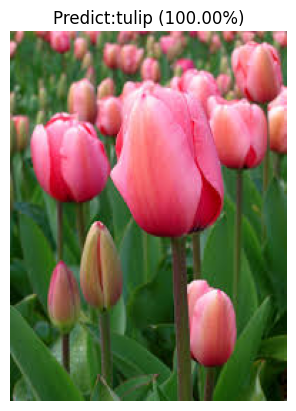

In [13]:
def predict_flower(img_path):
    # 1. Resmi yükle ve modele hazırla
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224)) # Model 224x224 bekliyor
    
    # 2. Normalizasyon (Eğitimde yaptığın gibi 0-1 arasına çekiyoruz)
    # Model içindeki Lambda katmanı bunu [-1, 1] yapacaktır.
    img_array = img_resized.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0) # (1, 224, 224, 3) formatına getirir

    # 3. Tahmin yap
    predictions = model.predict(img_array)
    class_idx = np.argmax(predictions) # En yüksek olasılıklı sınıfın indeksi
    confidence = np.max(predictions) * 100 # Doğruluk yüzdesi

    # 4. Sonucu görselleştir
    plt.imshow(img)
    plt.title(f"Predict:{class_names[class_idx]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()


#buraya indirdiğiniz resmin yolunu kopyalayın / şekli ters oluyo onu düzeltin 
predict_flower(r'C:\Users\beyza\OneDrive\Masaüstü\images.jpeg')